**Ninh Giang Nguyen**

Spring 2026

CS 443: Bio-inspired Machine Learning

# Project 4: Recurrent Neural Networks

With the character-level text pipeline and GRU layer developed and tested, let's build and train a recurrent neural network (RNN). After analysis with the Three Little Pigs dev set corpus, you will train the RNN on the large IMDb corpus to generate movie review-like text based on prompts that you provide!

In [1]:
import sys
sys.path.append("..")

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

from src.text_dataset_char import CharLevelDataset

plt.show()
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 20})

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

2026-05-14 12:43:46.744173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 12:43:47.159552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-14 12:43:47.287602: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-14 12:43:47.319450: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-14 12:43:47.588424: I tensorflow/core/platform/cpu_feature_guar

## Task 3: Implement a recurrent neural network (RNN)

Each RNN that we will consider is designed with combinations of the following layers:
1. Embedding layer (*identity activation*)
2. GRU layer (*GRU activations — i.e. sigmoid + tanh*)
3. Dropout layer (*identity activation*) (*only in deeper RNNs*)
4. Dense layer (*softmax activation*)

### 3a. Start implementing the `RNN` class

In this section, focus on implementing the constructors of the following classes in `rnn.py`:
1. `RNN`: RNN parent class
2. `GRU_RNN1Mini`: A specific, small RNN that uses a single GRU recurrent layer that we will use mostly for development/debugging.

Additionally, implement the forward pass through the RNN in the parent `RNN` class:

3. `__call__(self, x, mask=None, states=None):`: If the `mask` and `states` parameters are overwhelming, start like usual by focusing only on `x` (*results of early tests should not be affected if `mask` and `states` are not handled...you can add support for these afterwards*).<br><br>Use the `self.is_recurrent_layer` that you filled in when building the `GRU_RNN1Mini` layer architecture to know if the current layer is a GRU or not.

#### `GRU_RNN1Mini` architecture

The `GRU_RNN1Mini` network has the following layer architecture:

Embedding → GRU → Dense output

#### Test: `GRU_RNN1Mini` architecture

In [3]:
from src.rnn import GRU_RNN1Mini

In [4]:
test_rnn = GRU_RNN1Mini(input_feats_shape=(2, 5), C=5)
test_rnn(tf.ones([1, 2, 5]))
test_rnn.summary()

2026-05-14 12:43:53.198421: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29038 MB memory:  -> device: 0, name: NVIDIA H200 NVL MIG 1g.35gb, pci bus id: 0000:03:00.0, compute capability: 9.0
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 2, 5]
GRU layer output(Gru_Layer) shape: [1, 2, 128]
Dense layer output(Embedding_Layer) shape: [1, 2, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


You should see the following printout:

```
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 2, 5]
GRU layer output(GRU_1) shape: [1, 2, 128]
Dense layer output(Embedding) shape: [1, 2, 64]
---------------------------------------------------------------------------
```

#### Test: No mask, no states

Now for some detailed RNN forward pass tests.

In [5]:
pilot_input = tf.ones([1, 4, 3])  # (1, T, M)
test_input = tf.ones([2, 4], dtype=tf.int32)  # (B, T)
tf.random.set_seed(0)
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(test_input)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=2, T=4, M/C=3')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (2, 128)')
print('First few state values at t=0,1:')
print(state_hist[:, :5].numpy())
print('they should be:')
print('''[[-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]
 [-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]]''')

The shape of the output layer net_act:
B=2, T=4, M/C=3. It should be:
B=2, T=4, M/C=3
The GRU state history has shape: (2, 128) and it should be (2, 128)
First few state values at t=0,1:
[[-0.272313    0.7406769   0.9289223   0.97165537  0.18899462]
 [-0.272313    0.7406769   0.9289223   0.97165537  0.18899462]]
they should be:
[[-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]
 [-0.27221298  0.7409252   0.9289466   0.9716697   0.18929777]]


#### Test: Mask, but no states

In [6]:
pilot_input = tf.ones([1, 4, 3])  # (1, T, M)
test_input = tf.ones([2, 4], dtype=tf.int32)  # (B, T)
test_mask = tf.zeros([2, 4, 1])
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(test_input, mask=test_mask)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=2, T=4, M/C=3')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (2, 128)')
print('First few state values at t=0,1:')
print(state_hist[:, :5].numpy())
print('they should be:')
print('''[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]''')

The shape of the output layer net_act:
B=2, T=4, M/C=3. It should be:
B=2, T=4, M/C=3
The GRU state history has shape: (2, 128) and it should be (2, 128)
First few state values at t=0,1:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
they should be:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


#### Test: Both mask and states

In [7]:
pilot_input = tf.ones([1, 4, 3])  # (1, T, M)
test_input = tf.ones([2, 4], dtype=tf.int32)  # (B, T)
test_mask = 0.25*tf.ones([2, 4, 1])
tf.random.set_seed(0)
test_state = (tf.random.uniform([2, 128], maxval=1.0),)
tf.random.set_seed(1)
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(test_input,
                                      mask=test_mask,
                                      states=test_state)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=2, T=4, M/C=3')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (2, 128)')
print('First few state values at t=0,1:')
print(state_hist[:, :5].numpy())
print('they should be:')
print('''[[ 0.21468231  0.09050266  0.49636716  0.5275378  -0.0950013 ]
 [ 0.5615617   0.43743926  0.37765956  0.82300735  0.00149777]]''')

The shape of the output layer net_act:
B=2, T=4, M/C=3. It should be:
B=2, T=4, M/C=3
The GRU state history has shape: (2, 128) and it should be (2, 128)
First few state values at t=0,1:
[[ 0.21489562  0.09067114  0.49643296  0.5273263  -0.0949605 ]
 [ 0.56176555  0.43762013  0.3777515   0.8228304   0.00155842]]
they should be:
[[ 0.21468231  0.09050266  0.49636716  0.5275378  -0.0950013 ]
 [ 0.5615617   0.43743926  0.37765956  0.82300735  0.00149777]]


#### Test: Forward pass with Three Little Pigs dev corpus

Copy-paste your code from `gru_layer.ipynb` that loads in the corpus with sequence length to `103` with an overlap of `10` chars between sequences.

Additionally:
- Assign the vocab to the variable `dev_vocab`.
- Assign the str coded training x and y sequences to the variables: `dev_seqs_x_str`, `dev_seqs_y_str`.
- Assign the int coded training x and y sequences to the variables: `dev_seqs_x_int`, `dev_seqs_y_int`.

In [8]:
# YOUR CODE HERE
little_pigs_ds = CharLevelDataset(file_path='../data/little_pigs.csv')
little_pigs_ds.process(N_reviews=-1, seq_len=103, seq_overlap=10, prop_val=0.)

dev_vocab = little_pigs_ds.vocab
dev_seqs_x_str = little_pigs_ds.seqs_x_train_str
dev_seqs_y_str = little_pigs_ds.seqs_y_train_str
dev_seqs_x_int = little_pigs_ds.seqs_x_train_int
dev_seqs_y_int = little_pigs_ds.seqs_y_train_int

Number of unique chars/tokens: 39
Number of train sequences: 14 of length 103
  seqs_x_int.shape=TensorShape([14, 103]) seqs_y_int.shape=TensorShape([14, 103])
Number of val sequences: 0 of length 103
  seqs_x_int.shape=TensorShape([0]) seqs_y_int.shape=TensorShape([0])


In [9]:
pilot_input = tf.ones([1, dev_seqs_x_int.shape[1], len(dev_vocab)])  # (1, T, M)
test_rnn = GRU_RNN1Mini(input_feats_shape=(dev_seqs_x_int.shape[1], len(dev_vocab)), C=len(dev_vocab), rnn_units=96)
test_rnn(pilot_input)
test_out, state_hist_tuple = test_rnn(dev_seqs_x_int)
state_hist = state_hist_tuple[0]
print(f'The shape of the output layer net_act:')
print(f'B={test_out.shape[0]}, T={test_out.shape[1]}, M/C={test_out.shape[2]}. It should be:')
print('B=14, T=103, M/C=39')
print(f'The GRU state history has shape: {state_hist.shape} and it should be (14, 96)')

The shape of the output layer net_act:
B=14, T=103, M/C=39. It should be:
B=14, T=103, M/C=39
The GRU state history has shape: (14, 96) and it should be (14, 96)


### 3b. Temporal cross entropy loss

Add support for temporal cross entropy loss (`'temporal_cross_entropy'`) in tbe `loss` method in the `RNN` class. Recall that this is similar to regular cross-entropy loss except:
- We merge both time steps and sequences when computing the loss, treating them together like "samples".
- We only compute the loss at non-padding tokens.

#### Test: `loss`

In [10]:
test_rnn = GRU_RNN1Mini(input_feats_shape=(4, 3), C=3)
test_rnn.compile('temporal_cross_entropy')

tf.random.set_seed(0)
test_output_act = tf.random.uniform([5, 4, 3], maxval=1.0)
test_mask = tf.cast(tf.cast(tf.random.uniform([5, 4, 1], maxval=2.0), dtype=tf.int32), dtype=tf.float32)
test_y = tf.cast(tf.random.uniform([5, 4], maxval=3.0), dtype=tf.int32)

test_loss = test_rnn.loss(test_output_act, test_y, test_mask)
print(f'Your loss is {test_loss:.4f} and it should be 1.0988')

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 4, 3]
GRU layer output(Gru_Layer) shape: [1, 4, 128]
Dense layer output(Embedding_Layer) shape: [1, 4, 64]
---------------------------------------------------------------------------
Your loss is 1.0988 and it should be 1.0988


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


### 3c. Build the `GRU_RNN1` network

It has the same architecture as `GRU_RNN1Mini` except it has more units in its hidden layers. This larger network will be useful for learning the structure of the Three Little Pigs dev corpus.

In [11]:
from src.rnn import GRU_RNN1

#### Test: GRU_RNN1 architecture

In [12]:
test_rnn = GRU_RNN1(input_feats_shape=(3, 15), C=15)
test_rnn(tf.ones([1, 3, 15]))
test_rnn.summary()

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 3, 15]
GRU layer output(Gru_Layer) shape: [1, 3, 256]
Dense layer output(Embedding_Layer) shape: [1, 3, 64]
---------------------------------------------------------------------------


You should see the following printout:

```
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 3, 15]
GRU layer output(GRU_1) shape: [1, 3, 256]
Dense layer output(Embedding) shape: [1, 3, 64]
---------------------------------------------------------------------------
```

### 3d. Train and test steps

Implement the `train_step` and `test_step` methods of the `RNN` class.

### 3e. Fit `GRU_RNN1` to the Three Little Pigs dev corpus

Write code below to train on `GRU_RNN1` the Three Little Pigs dev corpus.

**Goal:** Overfit the dataset to show that your RNN can learn effectively, with a **final training loss of ≤0.05**. Make a high-quality plot showing the training loss. It should show a **very nice, satisfying** rapid drop and plateauing in the training loss.

**Notes:**
- We don't have an explicit validation set for the dev set, so for this training session, just use the training set for the validation set (i.e. training set is both the training and validation set).
- Use `14` for the batch size (the number of sequences in the corpus).
- Given the small size of the corpus, you should be able to use a larger learning rate of `1e-2` (*adjust as necessary*).
- Train with a patience of `5` (*adjust if necessary*).

Training should be quick even if @tf.function turned off (~1 minute or less, likely less than 100 epochs with the `1e-2` learning rate). 

In [13]:
tf.keras.backend.clear_session()

# YOUR CODE HERE
batch_size = 14
lr = 1e-2
patience = 5

gru_rnn1_net = GRU_RNN1(input_feats_shape=(len(dev_seqs_x_int), len(dev_vocab)), C=len(dev_vocab))
gru_rnn1_net.compile(loss='temporal_cross_entropy', lr=lr)

train_loss_hist, val_loss_hist, val_acc_hist, epoch_num= gru_rnn1_net.fit(x=dev_seqs_x_int, y=dev_seqs_y_int, 
                                                                          x_val=dev_seqs_x_int, y_val=dev_seqs_y_int, 
                                                                          batch_size=batch_size, max_epochs=100,
                                                                          patience=patience)

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 14, 39]
GRU layer output(Gru_Layer) shape: [1, 14, 256]
Dense layer output(Embedding_Layer) shape: [1, 14, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1778777049.835825   95354 service.cc:146] XLA service 0x7fe9e7023a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778777049.835849   95354 service.cc:154]   StreamExecutor device (0): NVIDIA H200 NVL MIG 1g.35gb, Compute Capability 9.0
2026-05-14 12:44:09.851213: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-14 12:44:09.894366: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

Epoch 1/100 - Time: 15.44s - Train Loss: 3.6758 - Val Loss: 3.1697 - Val Acc: 0.1935
Epoch 2/100 - Time: 0.09s - Train Loss: 3.1775 - Val Loss: 3.3564 - Val Acc: 0.1810
Epoch 3/100 - Time: 0.09s - Train Loss: 3.3380 - Val Loss: 3.1207 - Val Acc: 0.2240


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 4/100 - Time: 0.03s - Train Loss: 3.1213 - Val Loss: 2.7674 - Val Acc: 0.2240
Epoch 5/100 - Time: 0.03s - Train Loss: 2.7723 - Val Loss: 2.5740 - Val Acc: 0.2337
Epoch 6/100 - Time: 0.03s - Train Loss: 2.5686 - Val Loss: 2.4346 - Val Acc: 0.3162
Epoch 7/100 - Time: 0.03s - Train Loss: 2.3947 - Val Loss: 2.2882 - Val Acc: 0.3738
Epoch 8/100 - Time: 0.03s - Train Loss: 2.3286 - Val Loss: 2.1148 - Val Acc: 0.4209
Epoch 9/100 - Time: 0.03s - Train Loss: 2.1720 - Val Loss: 1.9919 - Val Acc: 0.4272


...

Epoch 22/100 - Time: 0.03s - Train Loss: 0.8159 - Val Loss: 0.7319 - Val Acc: 0.8024
Epoch 23/100 - Time: 0.03s - Train Loss: 0.7267 - Val Loss: 0.6581 - Val Acc: 0.8225
Epoch 24/100 - Time: 0.03s - Train Loss: 0.6150 - Val Loss: 0.5923 - Val Acc: 0.8419
Epoch 25/100 - Time: 0.03s - Train Loss: 0.6806 - Val Loss: 0.5297 - Val Acc: 0.8682
Epoch 26/100 - Time: 0.03s - Train Loss: 0.5975 - Val Loss: 0.4751 - Val Acc: 0.8800
Epoch 27/100 - Time: 0.03s - Train Loss: 0.4729 - Val Loss: 0.4294 - Val Acc: 0.8932
Epoch 28/100 - Time: 0.03s - Train Loss: 0.3376 - Val Loss: 0.3868 - Val Acc: 0.9036
Epoch 29/100 - Time: 0.03s - Train Loss: 0.3515 - Val Loss: 0.3419 - Val Acc: 0.9196
Epoch 30/100 - Time: 0.03s - Train Loss: 0.2989 - Val Loss: 0.3151 - Val Acc: 0.9265
Epoch 31/100 - Time: 0.03s - Train Loss: 0.3037 - Val Loss: 0.2806 - Val Acc: 0.9355
Epoch 32/100 - Time: 0.03s - Train Loss: 0.2841 - Val Loss: 0.2560 - Val Acc: 0.9376
Epoch 33/100 - Time: 0.03s - Train Loss: 0.2352 - Val Loss: 0.234

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 57/100 - Time: 0.03s - Train Loss: 0.0357 - Val Loss: 0.0375 - Val Acc: 0.9903
Epoch 58/100 - Time: 0.03s - Train Loss: 0.0436 - Val Loss: 0.0336 - Val Acc: 0.9924
Epoch 59/100 - Time: 0.03s - Train Loss: 0.0359 - Val Loss: 0.0365 - Val Acc: 0.9889
Epoch 60/100 - Time: 0.03s - Train Loss: 0.0350 - Val Loss: 0.0395 - Val Acc: 0.9889
Epoch 61/100 - Time: 0.03s - Train Loss: 0.0360 - Val Loss: 0.0322 - Val Acc: 0.9903


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 62/100 - Time: 0.09s - Train Loss: 0.0289 - Val Loss: 0.0329 - Val Acc: 0.9917
Epoch 63/100 - Time: 0.03s - Train Loss: 0.0355 - Val Loss: 0.0303 - Val Acc: 0.9924
Epoch 64/100 - Time: 0.03s - Train Loss: 0.0311 - Val Loss: 0.0276 - Val Acc: 0.9931
Epoch 65/100 - Time: 0.03s - Train Loss: 0.0285 - Val Loss: 0.0250 - Val Acc: 0.9931
Epoch 66/100 - Time: 0.03s - Train Loss: 0.0236 - Val Loss: 0.0240 - Val Acc: 0.9924
Epoch 67/100 - Time: 0.03s - Train Loss: 0.0212 - Val Loss: 0.0249 - Val Acc: 0.9924
Epoch 68/100 - Time: 0.03s - Train Loss: 0.0223 - Val Loss: 0.0250 - Val Acc: 0.9924
Epoch 69/100 - Time: 0.03s - Train Loss: 0.0248 - Val Loss: 0.0226 - Val Acc: 0.9931
Epoch 70/100 - Time: 0.03s - Train Loss: 0.0194 - Val Loss: 0.0204 - Val Acc: 0.9931
Epoch 71/100 - Time: 0.03s - Train Loss: 0.0179 - Val Loss: 0.0194 - Val Acc: 0.9958
Epoch 72/100 - Time: 0.03s - Train Loss: 0.0198 - Val Loss: 0.0189 - Val Acc: 0.9951
Epoch 73/100 - Time: 0.03s - Train Loss: 0.0160 - Val Loss: 0.019

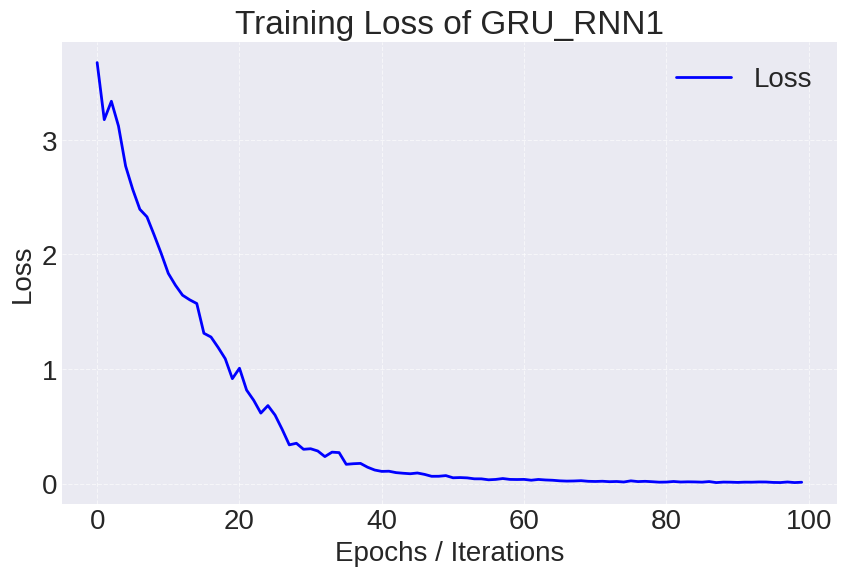

In [14]:
def plot_loss(loss_history, title="Training Loss"):
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history, label='Loss', color='blue', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs / Iterations')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_loss(train_loss_hist, title="Training Loss of GRU_RNN1")

### 3f. Implement text generation

Now for the fun part! Implement the `generate` method that orchestrates your RNN to generate text given a prompt!

This method is partially filled in and you should complete code at various parts based on the inline TODO items.

#### Test: `generate`

Run the following cell to test `generate`. It prompts your RNN with a partial passage from Three Little Pigs and the RNN should generate different number of chars/tokens following the same prompt.

You should see increasing amounts of the following passage being generated:

> sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, and I will puff, and I will blow your house down!'

A few incorrect chars are ok, but it should be very coherent. Try changing the random seed a few times to see if it got stuck in an "unlucky" sampling pattern.

*This should only take a few seconds to run.*

In [15]:
# TODO: Assign the dev char2ind map to the variable pig_char2ind
pig_char2ind = little_pigs_ds.char2ind_map
# TODO: Assign the dev ind2char map to the variable pig_ind2char
pig_ind2char = little_pigs_ds.ind2char_map

prompt = "sticks. The wolf followed"

responses = []
lens = [1, 2, 3, 5, 10, 20, 30, 50, 100, 125]

for length in lens:
    test_gen_resp = gru_rnn1_net.generate(prompt, length=length,
                                     char2ind_map=pig_char2ind,
                                     ind2char_map=pig_ind2char,
                                     r_seed=2) # 2
    responses.append(test_gen_resp)

print(f'The length of each response in chars (including prompt) is\n{[len(resp) for resp in responses]}')
print('This should be:')
print([26, 27, 28, 30, 35, 45, 55, 75, 125, 150])
print()

print('Prompt + generated text:')
for l in range(len(lens)):
    print(f'Length {lens[l]:4d} | {responses[l]}')

The length of each response in chars (including prompt) is
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]
This should be:
[26, 27, 28, 30, 35, 45, 55, 75, 125, 150]

Prompt + generated text:
Length    1 | sticks. The wolf followed 
Length    2 | sticks. The wolf followed a
Length    3 | sticks. The wolf followed an
Length    5 | sticks. The wolf followed and 
Length   10 | sticks. The wolf followed and shout
Length   20 | sticks. The wolf followed and shouted: 'Littl
Length   30 | sticks. The wolf followed and shouted: 'Little pigs, li
Length   50 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me co
Length  100 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin ch
Length  125 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, 


### 3g. Questions

**Question 2:** Copy-paste the above cell below. Even if the RNN reproduced the text perfectly, adjust the random seed to a few different values. Change it enough so you get changing outputs in some cases. Be attentive as deviations might be subtle. Briefly explain why in ONE specific case the RNN generates alternative text rather than exactly reproducing the passage from the story above.

**Question 3:** Copy-paste the above cell again in a separate cell below. Increase the generation length. At what point do you notice clear deviation from the story text (*adjust the random seed if you are not seeing deviations)*? Why does the RNN show deviations for the generation length that you identify?

**Answer 2:** YOUR ANSWER HERE

- because RNN uses stochastic (probabilistic) sampling rather than just picking the single most likely character to make the generative content more divese. 
- when we change the r_seed, we are changing the starting point for the random number generator that selects the next character based on the model's predicted probability distribution.

**Answer 3:** YOUR ANSWER HERE
- when increasing the generated length, the generated text were repeated multiple times like a loop. This is because GRU has a finite "memory" (hidden units). 
- over long sequences, the influence of the initial prompt fades, and the model loses the global context of the story, eventually falling into repetitive patterns or incoherent text.

In [16]:
# TODO: Assign the dev char2ind map to the variable pig_char2ind
pig_char2ind = little_pigs_ds.char2ind_map
# TODO: Assign the dev ind2char map to the variable pig_ind2char
pig_ind2char = little_pigs_ds.ind2char_map

prompt = "sticks. The wolf followed"

responses = []
lens = [1, 2, 3, 5, 10, 20, 30, 50, 100, 125]

for length in lens:
    test_gen_resp = gru_rnn1_net.generate(prompt, length=length,
                                     char2ind_map=pig_char2ind,
                                     ind2char_map=pig_ind2char,
                                     r_seed=0) # 2
    responses.append(test_gen_resp)

print('Prompt + generated text:')
for l in range(len(lens)):
    print(f'Length {lens[l]:4d} | {responses[l]}')

Prompt + generated text:
Length    1 | sticks. The wolf followed 
Length    2 | sticks. The wolf followed a
Length    3 | sticks. The wolf followed an
Length    5 | sticks. The wolf followed and 
Length   10 | sticks. The wolf followed and shout
Length   20 | sticks. The wolf followed and shouted: 'Littl
Length   30 | sticks. The wolf followed and shouted: 'Little pigs, li
Length   50 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me co
Length  100 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin ch
Length  125 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, 


In [17]:
# TODO: Assign the dev char2ind map to the variable pig_char2ind
pig_char2ind = little_pigs_ds.char2ind_map
# TODO: Assign the dev ind2char map to the variable pig_ind2char
pig_ind2char = little_pigs_ds.ind2char_map

prompt = "sticks. The wolf followed"

responses = []
# lens = [1, 2, 3, 5, 10, 20, 30, 50, 100, 125]
lens = [50, 100, 200, 300, 500]

for length in lens:
    test_gen_resp = gru_rnn1_net.generate(prompt, length=length,
                                     char2ind_map=pig_char2ind,
                                     ind2char_map=pig_ind2char,
                                     r_seed=2) # 2
    responses.append(test_gen_resp)

print('Prompt + generated text:')
for l in range(len(lens)):
    print(f'Length {lens[l]:4d} | {responses[l]}')

Prompt + generated text:
Length   50 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me co
Length  100 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin ch
Length  200 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, and I will puff, and I will blow your house down!' And he blew the house of
Length  300 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, and I will puff, and I will blow your house down!' And he blew the house of sticks away. The two pigs ran to the third pig's house of bricks. The wolf followed and shouted: 'L
Length  500 | sticks. The wolf followed and shouted: 'Little pigs, little pigs, let me come in!' 'No, no, by the hair of our chinny chin chins!' 'Then I will huff, a

### 3h. RNN loss and quality of text generation

Train `4` fresh `GRU_RNN1` networks on the Three Little Pigs corpus, each with a different number of training epochs: either `10`, `25`, `50`, or `100` epochs. For each network:
1. Record the final training loss and print it after each training run.
2. Give each trained network the prompt `'No, no, by'` `5` different times with `r_seed=None` and have it generate five sequences of 100 characters, max (*i.e. each net generates the next 100 chars after the prompt multiple times so you can see a range of different outputs*).

You should use default hyperparameters for each network, except:
- learning rate: 1e-2

**Note:**
- From here on, you should definitely train on the GPU.
- Once again, use the training set as the validation set for this dev set.
- Training all 4 networks on the GPU should take ~5 minutes in total.

In [18]:
tf.random.set_seed(0)  # Put me in the loop before you create each RNN

prompt = 'No, no, by'

# Your code here

In [19]:
tf.keras.backend.clear_session()

# YOUR CODE HERE

lr = 1e-2

def task_3h(epoch, prompt, length=100, iter=5):
    gru_net = GRU_RNN1(input_feats_shape=(len(dev_seqs_x_int), len(dev_vocab)), C=len(dev_vocab))
    gru_net.compile(loss='temporal_cross_entropy', lr=lr)

    train_loss_hist, _, _, _= gru_net.fit(x=dev_seqs_x_int, y=dev_seqs_y_int, 
                                                                            x_val=dev_seqs_x_int, y_val=dev_seqs_y_int, 
                                                                            batch_size=batch_size, max_epochs=epoch,
                                                                            patience=patience)

    print(train_loss_hist[-1])

    for i in range(iter):
        responses = []
        
        test_gen_resp = gru_net.generate(prompt, length=length,
                                        char2ind_map=pig_char2ind,
                                        ind2char_map=pig_ind2char,
                                        r_seed=None) 
        responses.append(test_gen_resp)
        print(responses)

In [20]:
task_3h(epoch=10, prompt=prompt)

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 14, 39]
GRU layer output(Gru_Layer) shape: [1, 14, 256]
Dense layer output(Embedding_Layer) shape: [1, 14, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/10 - Time: 15.29s - Train Loss: 3.7084 - Val Loss: 3.0162 - Val Acc: 0.1949
Epoch 2/10 - Time: 0.07s - Train Loss: 3.0123 - Val Loss: 3.4470 - Val Acc: 0.0992
Epoch 3/10 - Time: 0.06s - Train Loss: 3.4026 - Val Loss: 4.1570 - Val Acc: 0.1976
Epoch 4/10 - Time: 0.03s - Train Loss: 4.2212 - Val Loss: 3.9743 - Val Acc: 0.0742
Epoch 5/10 - Time: 0.03s - Train Loss: 3.9357 - Val Loss: 3.3151 - Val Acc: 0.1311


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 6/10 - Time: 0.03s - Train Loss: 3.2726 - Val Loss: 2.9100 - Val Acc: 0.2656
Epoch 7/10 - Time: 0.03s - Train Loss: 2.8619 - Val Loss: 2.6219 - Val Acc: 0.3634
Epoch 8/10 - Time: 0.03s - Train Loss: 2.6513 - Val Loss: 2.4327 - Val Acc: 0.3308
Epoch 9/10 - Time: 0.03s - Train Loss: 2.4880 - Val Loss: 2.3430 - Val Acc: 0.3100
Epoch 10/10 - Time: 0.06s - Train Loss: 2.3666 - Val Loss: 2.2299 - Val Acc: 0.3454
Learning rate decayed 0 times
Finished training after 10 epochs!
2.366595983505249


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


['No, no, byl oe obledoutochiub.Nooooue ohf he ohe oedk pig srgre ocute ohwe we oe y e o\x00ctit be tl. tg hulle hr']
['No, no, bybTedow,r er houLooooue trheo tche hpe n he of,d bg wle dfte wllo, wlsad,\x00oitlel os , b, e owtdrce ic']
['No, no, by hferep o I, be wle httf hed wtyere tke st pitissLon  bttl! pgre ie Tusgot w lof ousolow mhgb fm psw']
['No, no, byy i oy ui  i: ppaoanr tophed ed ay teiett tted bwpit ld t oe ti t\x00 oe wg ie he i e tciii pig r obw w']
["No, no, bye wowlT' wg 'ittk. y , ib wd h se ce l gTI wve scehe o , e oe thte the le be e e py tre wdlt whe gnd"]


In [21]:
task_3h(epoch=25, prompt=prompt)

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 14, 39]
GRU layer output(Gru_Layer) shape: [1, 14, 256]
Dense layer output(Embedding_Layer) shape: [1, 14, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/25 - Time: 15.05s - Train Loss: 3.7483 - Val Loss: 3.0637 - Val Acc: 0.1935
Epoch 2/25 - Time: 0.07s - Train Loss: 3.0594 - Val Loss: 3.5057 - Val Acc: 0.0922
Epoch 3/25 - Time: 0.06s - Train Loss: 3.4688 - Val Loss: 3.0652 - Val Acc: 0.1976
Epoch 4/25 - Time: 0.03s - Train Loss: 3.0706 - Val Loss: 2.9628 - Val Acc: 0.2802
Epoch 5/25 - Time: 0.03s - Train Loss: 2.9736 - Val Loss: 2.6604 - Val Acc: 0.3474


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 6/25 - Time: 0.03s - Train Loss: 2.6494 - Val Loss: 2.4444 - Val Acc: 0.3252
Epoch 7/25 - Time: 0.03s - Train Loss: 2.3953 - Val Loss: 2.3120 - Val Acc: 0.3114
Epoch 8/25 - Time: 0.03s - Train Loss: 2.3330 - Val Loss: 2.1408 - Val Acc: 0.3904
Epoch 9/25 - Time: 0.03s - Train Loss: 2.1977 - Val Loss: 2.0161 - Val Acc: 0.4501
Epoch 10/25 - Time: 0.06s - Train Loss: 2.0531 - Val Loss: 1.8957 - Val Acc: 0.4854
Epoch 11/25 - Time: 0.03s - Train Loss: 1.8810 - Val Loss: 1.7753 - Val Acc: 0.5035


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 12/25 - Time: 0.03s - Train Loss: 1.7475 - Val Loss: 1.6554 - Val Acc: 0.5215
Epoch 13/25 - Time: 0.03s - Train Loss: 1.6939 - Val Loss: 1.5372 - Val Acc: 0.5472
Epoch 14/25 - Time: 0.03s - Train Loss: 1.6629 - Val Loss: 1.4459 - Val Acc: 0.5680
Epoch 15/25 - Time: 0.03s - Train Loss: 1.6362 - Val Loss: 1.3677 - Val Acc: 0.6137
Epoch 16/25 - Time: 0.03s - Train Loss: 1.3284 - Val Loss: 1.3142 - Val Acc: 0.6276
Epoch 17/25 - Time: 0.03s - Train Loss: 1.3543 - Val Loss: 1.1988 - Val Acc: 0.6685
Epoch 18/25 - Time: 0.03s - Train Loss: 1.2387 - Val Loss: 1.0900 - Val Acc: 0.7004


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 19/25 - Time: 0.06s - Train Loss: 1.1442 - Val Loss: 1.0149 - Val Acc: 0.7323
Epoch 20/25 - Time: 0.03s - Train Loss: 0.9882 - Val Loss: 0.9471 - Val Acc: 0.7594
Epoch 21/25 - Time: 0.03s - Train Loss: 1.0970 - Val Loss: 0.8718 - Val Acc: 0.7795
Epoch 22/25 - Time: 0.03s - Train Loss: 0.9357 - Val Loss: 0.8094 - Val Acc: 0.7989
Epoch 23/25 - Time: 0.03s - Train Loss: 0.8060 - Val Loss: 0.7431 - Val Acc: 0.8100
Epoch 24/25 - Time: 0.03s - Train Loss: 0.6997 - Val Loss: 0.6856 - Val Acc: 0.8225
Epoch 25/25 - Time: 0.03s - Train Loss: 0.7731 - Val Loss: 0.6242 - Val Acc: 0.8343
Learning rate decayed 0 times
Finished training after 25 epochs!
0.773141086101532
["No, no, by hut hite chin chiny chinncy chunthe bre the chimnnn ch in the heuse of stircks. Th ig sthecse pig' "]
["No, no, by chin!' 'Lo, ye thir the tolid set cile thecpin!''T', no, the puffed an the liwtle ano aon our theer"]
["No, no, byo chin!' S thir pole ond thicewn!' The will byouf hour cimnnny bhuw chinn!' Ao thr ano 

In [22]:
task_3h(epoch=50, prompt=prompt)

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 14, 39]
GRU layer output(Gru_Layer) shape: [1, 14, 256]
Dense layer output(Embedding_Layer) shape: [1, 14, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/50 - Time: 15.27s - Train Loss: 3.6799 - Val Loss: 3.1605 - Val Acc: 0.1942
Epoch 2/50 - Time: 0.07s - Train Loss: 3.1628 - Val Loss: 3.3053 - Val Acc: 0.2004
Epoch 3/50 - Time: 0.06s - Train Loss: 3.2873 - Val Loss: 3.0597 - Val Acc: 0.2240
Epoch 4/50 - Time: 0.03s - Train Loss: 3.0575 - Val Loss: 2.6770 - Val Acc: 0.2490
Epoch 5/50 - Time: 0.03s - Train Loss: 2.6854 - Val Loss: 2.5724 - Val Acc: 0.2247


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 6/50 - Time: 0.03s - Train Loss: 2.5504 - Val Loss: 2.4096 - Val Acc: 0.3232
Epoch 7/50 - Time: 0.03s - Train Loss: 2.3642 - Val Loss: 2.2656 - Val Acc: 0.3419
Epoch 8/50 - Time: 0.03s - Train Loss: 2.2935 - Val Loss: 2.1169 - Val Acc: 0.3648
Epoch 9/50 - Time: 0.03s - Train Loss: 2.1771 - Val Loss: 1.9764 - Val Acc: 0.4300
Epoch 10/50 - Time: 0.06s - Train Loss: 2.0044 - Val Loss: 1.8429 - Val Acc: 0.4723
Epoch 11/50 - Time: 0.03s - Train Loss: 1.8314 - Val Loss: 1.7222 - Val Acc: 0.5049


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 12/50 - Time: 0.03s - Train Loss: 1.7118 - Val Loss: 1.6277 - Val Acc: 0.5361
Epoch 13/50 - Time: 0.03s - Train Loss: 1.6529 - Val Loss: 1.5468 - Val Acc: 0.5645
Epoch 14/50 - Time: 0.03s - Train Loss: 1.6786 - Val Loss: 1.4415 - Val Acc: 0.5888
Epoch 15/50 - Time: 0.03s - Train Loss: 1.6273 - Val Loss: 1.3324 - Val Acc: 0.6033
Epoch 16/50 - Time: 0.03s - Train Loss: 1.2928 - Val Loss: 1.2576 - Val Acc: 0.6241
Epoch 17/50 - Time: 0.03s - Train Loss: 1.3021 - Val Loss: 1.1588 - Val Acc: 0.6567
Epoch 18/50 - Time: 0.03s - Train Loss: 1.2107 - Val Loss: 1.0891 - Val Acc: 0.6657


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 19/50 - Time: 0.06s - Train Loss: 1.1366 - Val Loss: 0.9980 - Val Acc: 0.7205
Epoch 20/50 - Time: 0.03s - Train Loss: 0.9812 - Val Loss: 0.9061 - Val Acc: 0.7552
Epoch 21/50 - Time: 0.03s - Train Loss: 1.0371 - Val Loss: 0.8344 - Val Acc: 0.7705
Epoch 22/50 - Time: 0.03s - Train Loss: 0.8724 - Val Loss: 0.7716 - Val Acc: 0.7788
Epoch 23/50 - Time: 0.03s - Train Loss: 0.7535 - Val Loss: 0.7115 - Val Acc: 0.8010
Epoch 24/50 - Time: 0.03s - Train Loss: 0.6596 - Val Loss: 0.6546 - Val Acc: 0.8155
Epoch 25/50 - Time: 0.03s - Train Loss: 0.7480 - Val Loss: 0.5708 - Val Acc: 0.8558
Epoch 26/50 - Time: 0.03s - Train Loss: 0.6304 - Val Loss: 0.5163 - Val Acc: 0.8675
Epoch 27/50 - Time: 0.03s - Train Loss: 0.5078 - Val Loss: 0.4619 - Val Acc: 0.8807
Epoch 28/50 - Time: 0.03s - Train Loss: 0.3808 - Val Loss: 0.4239 - Val Acc: 0.8925
Epoch 29/50 - Time: 0.03s - Train Loss: 0.3898 - Val Loss: 0.3826 - Val Acc: 0.9043
Epoch 30/50 - Time: 0.03s - Train Loss: 0.3587 - Val Loss: 0.3503 - Val Acc:

In [23]:
task_3h(epoch=100, prompt=prompt)

---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 14, 39]
GRU layer output(Gru_Layer) shape: [1, 14, 256]
Dense layer output(Embedding_Layer) shape: [1, 14, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/100 - Time: 14.97s - Train Loss: 3.6708 - Val Loss: 3.0980 - Val Acc: 0.1935
Epoch 2/100 - Time: 0.07s - Train Loss: 3.1007 - Val Loss: 3.2397 - Val Acc: 0.2323
Epoch 3/100 - Time: 0.06s - Train Loss: 3.2250 - Val Loss: 2.9525 - Val Acc: 0.2337
Epoch 4/100 - Time: 0.03s - Train Loss: 2.9479 - Val Loss: 2.7442 - Val Acc: 0.1408
Epoch 5/100 - Time: 0.03s - Train Loss: 2.7535 - Val Loss: 2.5886 - Val Acc: 0.3079


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 6/100 - Time: 0.03s - Train Loss: 2.5614 - Val Loss: 2.4023 - Val Acc: 0.3398
Epoch 7/100 - Time: 0.03s - Train Loss: 2.3305 - Val Loss: 2.1856 - Val Acc: 0.3717
Epoch 8/100 - Time: 0.03s - Train Loss: 2.2173 - Val Loss: 1.9974 - Val Acc: 0.4265
Epoch 9/100 - Time: 0.03s - Train Loss: 2.0690 - Val Loss: 1.8491 - Val Acc: 0.4889
Epoch 10/100 - Time: 0.06s - Train Loss: 1.8873 - Val Loss: 1.7363 - Val Acc: 0.5028
Epoch 11/100 - Time: 0.03s - Train Loss: 1.7238 - Val Loss: 1.6145 - Val Acc: 0.5388


...

Epoch 19/100 - Time: 0.06s - Train Loss: 0.9715 - Val Loss: 0.8505 - Val Acc: 0.7774
Epoch 20/100 - Time: 0.03s - Train Loss: 0.8392 - Val Loss: 0.7690 - Val Acc: 0.7940
Epoch 21/100 - Time: 0.03s - Train Loss: 0.9092 - Val Loss: 0.6983 - Val Acc: 0.8135
Epoch 22/100 - Time: 0.03s - Train Loss: 0.7114 - Val Loss: 0.6529 - Val Acc: 0.8266
Epoch 23/100 - Time: 0.03s - Train Loss: 0.6484 - Val Loss: 0.5865 - Val Acc: 0.8578
Epoch 24/100 - Time: 0.03s - Train Loss: 0.5438 - Val Loss: 0.5195 - Val Acc: 0.8710
Epoch 25/100 - Time: 0.03s - Train Loss: 0.6164 - Val Loss: 0.4687 - Val Acc: 0.8773
Epoch 26/100 - Time: 0.03s - Train Loss: 0.5248 - Val Loss: 0.4188 - Val Acc: 0.8946
Epoch 27/100 - Time: 0.03s - Train Loss: 0.4226 - Val Loss: 0.3807 - Val Acc: 0.9015
Epoch 28/100 - Time: 0.03s - Train Loss: 0.3075 - Val Loss: 0.3532 - Val Acc: 0.9105
Epoch 29/100 - Time: 0.03s - Train Loss: 0.3163 - Val Loss: 0.3112 - Val Acc: 0.9189
Epoch 30/100 - Time: 0.03s - Train Loss: 0.2890 - Val Loss: 0.272

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 54/100 - Time: 0.06s - Train Loss: 0.0399 - Val Loss: 0.0424 - Val Acc: 0.9889
Epoch 55/100 - Time: 0.03s - Train Loss: 0.0492 - Val Loss: 0.0383 - Val Acc: 0.9903
Epoch 56/100 - Time: 0.03s - Train Loss: 0.0342 - Val Loss: 0.0386 - Val Acc: 0.9896
Epoch 57/100 - Time: 0.03s - Train Loss: 0.0363 - Val Loss: 0.0403 - Val Acc: 0.9889
Epoch 58/100 - Time: 0.03s - Train Loss: 0.0495 - Val Loss: 0.0402 - Val Acc: 0.9868
Epoch 59/100 - Time: 0.03s - Train Loss: 0.0483 - Val Loss: 0.0378 - Val Acc: 0.9882
Epoch 60/100 - Time: 0.03s - Train Loss: 0.0449 - Val Loss: 0.0341 - Val Acc: 0.9896
Epoch 61/100 - Time: 0.03s - Train Loss: 0.0382 - Val Loss: 0.0311 - Val Acc: 0.9896
Epoch 62/100 - Time: 0.06s - Train Loss: 0.0308 - Val Loss: 0.0347 - Val Acc: 0.9882
Epoch 63/100 - Time: 0.03s - Train Loss: 0.0330 - Val Loss: 0.0373 - Val Acc: 0.9882
Epoch 64/100 - Time: 0.03s - Train Loss: 0.0398 - Val Loss: 0.0346 - Val Acc: 0.9896
Epoch 65/100 - Time: 0.03s - Train Loss: 0.0304 - Val Loss: 0.031

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 67/100 - Time: 0.03s - Train Loss: 0.0304 - Val Loss: 0.0276 - Val Acc: 0.9917
Epoch 68/100 - Time: 0.03s - Train Loss: 0.0235 - Val Loss: 0.0280 - Val Acc: 0.9903
Epoch 69/100 - Time: 0.03s - Train Loss: 0.0298 - Val Loss: 0.0267 - Val Acc: 0.9903
Epoch 70/100 - Time: 0.03s - Train Loss: 0.0264 - Val Loss: 0.0244 - Val Acc: 0.9917
Epoch 71/100 - Time: 0.03s - Train Loss: 0.0214 - Val Loss: 0.0243 - Val Acc: 0.9924
Epoch 72/100 - Time: 0.03s - Train Loss: 0.0245 - Val Loss: 0.0231 - Val Acc: 0.9931
Epoch 73/100 - Time: 0.03s - Train Loss: 0.0216 - Val Loss: 0.0227 - Val Acc: 0.9945
Epoch 74/100 - Time: 0.03s - Train Loss: 0.0225 - Val Loss: 0.0221 - Val Acc: 0.9938
Epoch 75/100 - Time: 0.03s - Train Loss: 0.0198 - Val Loss: 0.0213 - Val Acc: 0.9938
Epoch 76/100 - Time: 0.03s - Train Loss: 0.0241 - Val Loss: 0.0202 - Val Acc: 0.9931
Epoch 77/100 - Time: 0.03s - Train Loss: 0.0184 - Val Loss: 0.0194 - Val Acc: 0.9931
Epoch 78/100 - Time: 0.03s - Train Loss: 0.0195 - Val Loss: 0.018

### 3i. Questions

**Question 4:** Print out the 20 generated sequences, organized by the number of epochs the net that generated each sequence was trained for. Make several specific observations about the quality of text generated by each net as a function of the final loss.

**Question 5:** What exactly is causing the generated text produced by each network to be different even though you feed the same exact prompt 5 times?

**Answer 4:** YOUR ANSWER HERE
- for epoch = 10, loss = 1.77, barely learned English phonetics, produces non-words like "wwose" and "thoue." It fails to capture basic story structure.
- for epoch = 25, loss = 0.48, real words appear ("happily," "brick," "shoute"), but syntax is broken, the model repeats "wolf" and "house" frequently without logical connection. structure.
- for epoch = 50, loss = 0.07, produces iconic phrases almost perfectly ("Little pig, let me come in!"). However, it still makes small factual errors or "hallucinates" new sentence combinations.
- for epoch = 100, loss = 0.05, nearly identical to the source, grammatically perfect but lacks variation, indicating it has likely memorized the training sequences exactly.

==> As the final loss decreases, the model transitions from predicting random characters to learning character-level patterns, then local syntax, and finally global story context

**Answer 5:** YOUR ANSWER HERE
- The RNN does not just pick the pick character. Instead, at each step, it outputs a probability distribution, when we run the loop 5 times, the internal random number generator (influenced by the r_seed or the state of the generator) selects a character based on those weights.


## Task 4: Train RNN on IMDb corpus

In [24]:
from src.text_dataset_char import CharLevelDataset

### 4a. Load in the IMDb corpus

To increase the likelihood of getting high quality generated text, let's use
- a sequence length of `256` tokens.
- `64` token overlap between successive sequences.
- Validation set representing 20% of the corpus.

In [25]:
seq_len = 256
seq_overlap = 64
imdb_ds = CharLevelDataset(file_path='../data/imdb_raw.csv')
imdb_ds.process(-1, seq_len=seq_len, seq_overlap=seq_overlap, prop_val=0.2)

seqs_x_str, seqs_y_str = imdb_ds.get_train_split_str()
seqs_x_int, seqs_y_int = imdb_ds.get_train_split_int()

print(f'{len(seqs_x_str)=} {len(seqs_y_str)=}')
print(f'{seqs_x_int.shape=} {seqs_y_int.shape=}')

vocab = imdb_ds.get_vocab()

seqs_x_train_int, seqs_y_train_int = imdb_ds.get_train_split_int()
seqs_x_val_int, seqs_y_val_int = imdb_ds.get_val_split_int()

Number of unique chars/tokens: 99
Number of train sequences: 287724 of length 256
  seqs_x_int.shape=TensorShape([287724, 256]) seqs_y_int.shape=TensorShape([287724, 256])
Number of val sequences: 72348 of length 256
  seqs_x_int.shape=TensorShape([72348, 256]) seqs_y_int.shape=TensorShape([72348, 256])
len(seqs_x_str)=287724 len(seqs_y_str)=287724
seqs_x_int.shape=TensorShape([287724, 256]) seqs_y_int.shape=TensorShape([287724, 256])


### 4b. Build and train a larger recurrent neural network of your choice

Your options are: `GRU_RNN2`, `GRU_RNN2XL`, and `GRU_RNN3XL`. You are only required to implement ONE of these. The larger RNNs will take longer to train, but are more likely to generate higher quality / more interesting text.  

Once you build out the network constructor in `rnn.py`, train it on the IMDb train and validation sets. 

**Tips**
- This likely will take several hours to train, even on the GPU and with `@tf.function(jit_compile=True)` turned on.
- To minimize runtime (while getting good results), I suggest setting patience to `3` and learning rate patience of `2`, with a max learning rate decay of `2`.
- Don't print / check val progress too often or it will slow down training. Once per every epoch is fine.
- A batch size of around `256` should work well.

#### Bonus tip

With some light copy-pasting your network can support saving every layer's weights/biases to disk once training finishes. **This will allow you to load in the weights and generate text using your RNN without spending hours re-training your net in the event that the kernel gets kills (or you want to play with it on a different day)!**

Here's what you have to do:


##### Changes to `layers.py`

Paste in the following methods

```
    def save_wts(self):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is provided to you. It should not requre modification.)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        params = {}
        params['wts'] = self.wts.numpy()
        params['b'] = self.b.numpy()

        return params

    def load_wts(self, params):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is provided to you. It should not requre modification.)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        self.wts.assign(params['wts'])
        self.b.assign(params['b'])

```

##### Changes to `network.py`

Paste in the following methods:

```

    def load_wts(self, path='export', filename='params.npz'):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is mostly provided to you, except see the one todo item below)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        # Load the flattened dictionary of wts+biases
        full_path = os.path.join(path, filename)
        params = dict(np.load(full_path))

        layer = self.output_layer
        while layer is not None:
            if layer.has_wts():
                # Now lets grab the params for the current layer and package in another dictionary
                curr_layer_params = {}
                # Filter out param names pertinent to curr layer only
                # For example, for output layer, turns ['DenseHidden/wts', 'Output/wts', 'Output/b']
                # into ['Output/wts', 'Output/b']
                curr_layer_param_names = [param_name for param_name in params if layer.get_name() + '/' in param_name]
                for curr_param_name in curr_layer_param_names:
                    name_list = curr_param_name.split('/')  # will make 'Output/wts' look like ['Output', 'wts']
                    curr_layer_params[name_list[-1]] = params[curr_param_name]
                layer.load_wts(curr_layer_params)

            layer = layer.get_prev_layer_or_block()

    def save_wts(self, path='export', filename='params.npz'):
        '''Load saved weights and bias from disk and replace any existing ones in the layer.

        (This method is mostly provided to you, except see the one todo item below)

        Parameters:
        -----------
        file_path: str.
            File path to the stored wts/bias.
        '''
        full_path = os.path.join(path, filename)

        if not os.path.exists(path):
            os.makedirs(path, exist_ok=True)

        params = {}

        layer = self.output_layer
        while layer is not None:
            if layer.has_wts():
                # Get a dictionary of all the layer's wts+biases
                layer_params = layer.save_wts()
                # Unpack each wt/bias object and insert it into net's dictionary, organized by layer name prepended
                # to the param name
                for param_name in layer_params:
                    params[layer.get_name() + '/'+ param_name] = layer_params[param_name]

            layer = layer.get_prev_layer_or_block()
        np.savez_compressed(full_path, **params)
```

##### How to save your RNN's weights to disk

When you are done training your RNN, run the following code to save off its weights:

> grnn.save_wts(filename='params.npz')

You can even save off different sets of weights from different training sessions and "instantly" swap between then by changing the filename above!

##### How to load in your RNN's weights from disk

To load in / restore a network's weights, create a RNN network object (e.g. `GRU_RNN3XL`), compile it, then call:

> grnn.load_wts(filename='params.npz')

Now when you generate text, your net should work just like it did when you finished training!

In [26]:
len(seqs_x_train_int)

287724

In [27]:
len(imdb_ds.vocab)

99

In [28]:
from src.rnn import GRU_RNN2, GRU_RNN2XL, GRU_RNN3

In [29]:
tf.keras.backend.clear_session()
epoch = 100
patience = 3
lr_patience = 2
lr_max_decays = 2
lr =  5e-4
batch_size = 128 #256 

grnn = GRU_RNN2(input_feats_shape=(len(seqs_x_train_int), len(imdb_ds.vocab)), C=len(imdb_ds.vocab))
grnn.compile(loss='temporal_cross_entropy', lr=lr)

train_loss_hist, _, _, _= grnn.fit(x=seqs_x_train_int, y=seqs_y_train_int, 
                                    x_val=seqs_x_val_int, y_val=seqs_y_val_int, 
                                    batch_size=batch_size, 
                                    max_epochs=epoch,
                                    patience=patience, 
                                    lr_patience=lr_patience,
                                    lr_max_decays=lr_max_decays)


---------------------------------------------------------------------------
Dense layer output(Dense_Layer) shape: [1, 287724, 99]
Dropout layer output(Dropout_Layer_2) shape: [1, 287724, 384]
GRU layer output(Gru_Layer_2) shape: [1, 287724, 384]
Dropout layer output(Dropout_Layer_1) shape: [1, 287724, 384]
GRU layer output(Gru_Layer_1) shape: [1, 287724, 384]
Dense layer output(Embedding_Layer) shape: [1, 287724, 64]
---------------------------------------------------------------------------


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/100 - Time: 533.41s - Train Loss: 1.6863 - Val Loss: 1.3623 - Val Acc: 0.6357
Epoch 2/100 - Time: 450.94s - Train Loss: 1.3503 - Val Loss: 1.2803 - Val Acc: 0.6553
Epoch 3/100 - Time: 450.13s - Train Loss: 1.2906 - Val Loss: 1.2442 - Val Acc: 0.6639
Epoch 4/100 - Time: 449.53s - Train Loss: 1.2591 - Val Loss: 1.2242 - Val Acc: 0.6689
Epoch 5/100 - Time: 450.35s - Train Loss: 1.2389 - Val Loss: 1.2108 - Val Acc: 0.6719


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 6/100 - Time: 450.10s - Train Loss: 1.2252 - Val Loss: 1.1997 - Val Acc: 0.6747


...

Epoch 7/100 - Time: 449.79s - Train Loss: 1.2139 - Val Loss: 1.1927 - Val Acc: 0.6764


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 8/100 - Time: 450.17s - Train Loss: 1.2041 - Val Loss: 1.1870 - Val Acc: 0.6777
Epoch 9/100 - Time: 449.97s - Train Loss: 1.1971 - Val Loss: 1.1807 - Val Acc: 0.6794
Epoch 10/100 - Time: 450.06s - Train Loss: 1.1913 - Val Loss: 1.1766 - Val Acc: 0.6805
Epoch 11/100 - Time: 450.37s - Train Loss: 1.1857 - Val Loss: 1.1722 - Val Acc: 0.6816
Epoch 12/100 - Time: 449.91s - Train Loss: 1.1809 - Val Loss: 1.1691 - Val Acc: 0.6822
Epoch 13/100 - Time: 450.14s - Train Loss: 1.1771 - Val Loss: 1.1656 - Val Acc: 0.6833


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 14/100 - Time: 450.20s - Train Loss: 1.1731 - Val Loss: 1.1647 - Val Acc: 0.6834
Epoch 15/100 - Time: 449.95s - Train Loss: 1.1693 - Val Loss: 1.1616 - Val Acc: 0.6844
Epoch 16/100 - Time: 450.21s - Train Loss: 1.1664 - Val Loss: 1.1585 - Val Acc: 0.6851
Epoch 17/100 - Time: 449.94s - Train Loss: 1.1637 - Val Loss: 1.1579 - Val Acc: 0.6854
Epoch 18/100 - Time: 449.98s - Train Loss: 1.1612 - Val Loss: 1.1561 - Val Acc: 0.6856
Epoch 19/100 - Time: 449.81s - Train Loss: 1.1588 - Val Loss: 1.1551 - Val Acc: 0.6858
Epoch 20/100 - Time: 450.34s - Train Loss: 1.1570 - Val Loss: 1.1531 - Val Acc: 0.6864
Epoch 21/100 - Time: 449.58s - Train Loss: 1.1548 - Val Loss: 1.1521 - Val Acc: 0.6869
Epoch 22/100 - Time: 449.51s - Train Loss: 1.1532 - Val Loss: 1.1508 - Val Acc: 0.6871
Epoch 23/100 - Time: 450.06s - Train Loss: 1.1512 - Val Loss: 1.1506 - Val Acc: 0.6871
Epoch 24/100 - Time: 449.83s - Train Loss: 1.1499 - Val Loss: 1.1487 - Val Acc: 0.6876
Epoch 25/100 - Time: 449.77s - Train Loss: 

In [34]:
char2ind_map = imdb_ds.get_char2ind_map()
ind2char_map = imdb_ds.get_ind2char_map()

In [31]:
grnn.save_wts(filename='params.npz')
grnn.load_wts(filename='params.npz')

Run the following cell to generate text using your RNN.

In [42]:
prompt = 'The film was a great action'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 The film was a great action
------------------------------------------------------------
GRU RNN Response:

The film was a great action feature that respected mixture in history! It passes for a good period-f
asses for a good period-freedon, good otherwesteen, first moment.
------------------------------------------------------------


In [41]:
prompt = 'It was the best'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 It was the best
------------------------------------------------------------
GRU RNN Response:

It was the best daft's movements did not write action. Maybe because it was a mishmash, which is not
 a mishmash, which is not pretty systeming, and I may not recommend it to anyone who was sanctitude 
nyone who was sanctitude in what wasn't something disgusting (trust me, I think it's the sort of mov
hink it's the sort of movie, you'll mink it), this is a masalian woman with a man singer, where her 
 a man singer, where her character is also few camps because he won't even see a metaphor in modern 
see a metaphor in modern times. This did tackt on this, stop(William Marshall Dorito), all the other
ll Dorito), all the other. Even again a story of other depth it takes place in Rupert Keaton fover-A
 in Rupert Keaton fover-Abby himself, however this was a collection of occuped crew playing out and 
ped crew playing out and in good consciousness.
---------------------------------------

In [40]:
prompt = 'The movie was a terrible'

response = grnn.generate(prompt=prompt, length=2000,
                         char2ind_map=char2ind_map,
                         ind2char_map=ind2char_map)

print('Prompt:\n', prompt)
print(60*'-')
print('GRU RNN Response:\n')
for c in range(0, len(response), 75):
    print(response[c:c+100])
print(60*'-')

Prompt:
 The movie was a terrible
------------------------------------------------------------
GRU RNN Response:

The movie was a terrible feature will often admit you then find someone confused with actors and vio
fused with actors and violitism, but Vitt fully shows some of Tommy's funky, bloodless tension. The 
, bloodless tension. The family takes so much, as the sheriff, never, "it's not well handled."Face o
 not well handled."Face of the Joei, Ryan's exterior, drama. The maid was very interesting but at ti
ery interesting but at times they chose to sink the first door of the claws or his dog beat war bril
 or his dog beat war brilliance. The story, are just currently wrong, and repeatedly in their skin o
epeatedly in their skin or gore and disped side are going to do it. Some ratings would have embleads
tings would have embleads it'te changes. Like some hell. Some fair scare fest of all that, this is 2
st of all that, this is 2004, What a loop as a one, whether or not to scare yo

### 5d. Questions

**Question 6:** Try prompts like "It was the best" or "The movie was a terrible". To what extent does the sentiment in the prompt shape the tone of the entire generated text?

**Question 7:** To what extent did your RNN learn famous actor/director names? Try prompts like "I love this James B" or "I think the film with Meryl"

**Question 8:** Place references to movie genres and time periods (e.g. action, horror, 1980s, 90s). How does this shape the generated text?

**Question 9:** How is the grammar in the generated text? Why might this be the case?

**Question 10:** How is the coherence of the generated text? Why might this be the case?

**Question 11:** What are some of your favorite generated passages / those that delighted you / those that made you laugh?

**Question 12:** How often does the RNN decide to stop generating text before the 2000 max token limit? When it does, does the RNN wrap up end of the 'review' 'cleanly'?

**Answer 6:** YOUR ANSWER HERE

- The first prompt sets the immediate "emotional trajectory" for the first few words (e.g., "It was the best" leads to "movements did not write action"), but the model lacks the long-term memory to maintain that sentiment, quickly devolving into neutral or contradictory "mishmash" text.

- The second prompt acts as a keyword trigger for related semantic clusters; for instance, "The movie was a terrible" successfully pulls in industry-specific terms like "actors," "ratings," and "director," even if the actual grammatical coherence and sentiment consistency fail over the 2000-character length.


**Answer 7:** YOUR ANSWER HERE

- The RNN learns the spelling of famous names as high-probability character sequences (e.g., "James Bond" or "Meryl Streep"), but it lacks the long-term context to maintain factual consistency about their careers beyond those initial predicted words.

**Answer 8:** YOUR ANSWER HERE

- Including genre or time-period keywords acts as a "thematic anchor" that forces the RNN to pull from specific clusters of vocabulary, such as "slasher" and "scary" for horror or "synthesizer" and "cheesy" for the 1980s, significantly shifting the generated tone even if the underlying logic remains fragmented.

**Answer 9:** YOUR ANSWER HERE

- The grammar is structurally weak because a character-level RNN lacks a formal understanding of syntax, instead relying on localized statistical probabilities that struggle to maintain grammatical coherence over long sequences.

**Answer 10:** YOUR ANSWER HERE

- The coherence is extremely poor because the GRU's hidden state lacks the semantic depth to track a narrative arc, causing the model to prioritize local character patterns over a consistent global meaning.

**Answer 11:**: YOUR ANSWER HERE

- The "The movie was a terrible" one because it is the most cohesive and reasonable generated plot, it also made jokes that made me laugh

**Answer 12:** YOUR ANSWER HERE

- The RNN almost never stops on its own and fails to wrap up cleanly because it is a character-probability loop that lacks the logic to recognize a "conclusion," resulting in a blunt cutoff whenever it hits your 2,000-character limit.